# 04 — Sentiment Analysis
measuring reddit sentiment about AI's impact on wikipedia using VADER and RoBERTa.

hypothesis: sentiment shifted from curious/neutral to concerned/negative as the AI content debate grew.

In [2]:
import sys, os
sys.path.insert(0, os.path.abspath('../..'))

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from src.sentiment import vader_sentiment, roberta_sentiment, aggregate_sentiment_by_month
from src.data_prep import add_pre_post_chatgpt

sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (14, 6)

CHATGPT_LAUNCH = pd.Timestamp("2022-11-30")

In [3]:
reddit = pd.read_csv("../../data/raw/reddit_raw/reddit_ai_wikipedia_posts.csv", parse_dates=["date"])
print(f"loaded {len(reddit)} posts")

loaded 684 posts


## 1. VADER Sentiment — Fast Baseline
rule-based, no model to download, works well for social media text

In [4]:
# run vader on all posts
reddit = vader_sentiment(reddit, text_col="text")

print("vader sentiment distribution:")
print(reddit["vader_label"].value_counts())
print(f"\nmean compound score: {reddit['vader_compound'].mean():.3f}")

vader sentiment distribution:
vader_label
positive    387
neutral     161
negative    136
Name: count, dtype: int64

mean compound score: 0.276


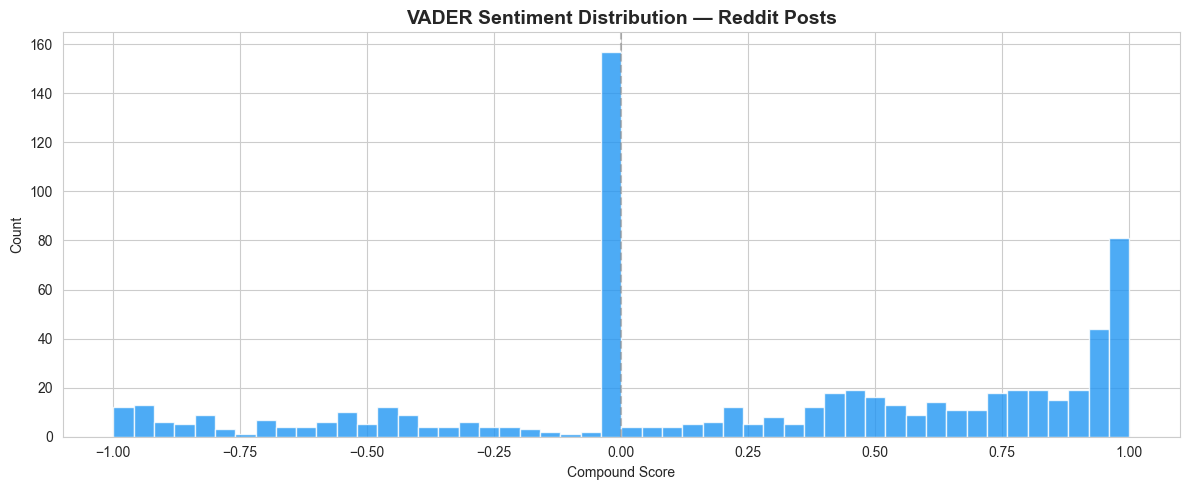

In [5]:
# sentiment distribution histogram
fig, ax = plt.subplots(figsize=(12, 5))
ax.hist(reddit["vader_compound"], bins=50, color="#2196F3", edgecolor="white", alpha=0.8)
ax.axvline(x=0, color="gray", linestyle="--", alpha=0.5)
ax.set_title("VADER Sentiment Distribution — Reddit Posts", fontsize=14, fontweight="bold")
ax.set_xlabel("Compound Score")
ax.set_ylabel("Count")
plt.tight_layout()
plt.savefig("../../reports/reddit_reports/vader_distribution.png", dpi=150, bbox_inches="tight")
plt.show()

## 2. RoBERTa Sentiment — Transformer Model
cardiffnlp/twitter-roberta trained on ~124M tweets, much better at understanding context.

**note**: first run will download the model (~500MB), takes a few minutes

In [6]:
# run roberta — this is the ml component
print("running roberta sentiment analysis (this may take a few minutes)...")
reddit = roberta_sentiment(reddit, text_col="text")

print("\nroberta sentiment distribution:")
print(reddit["roberta_label"].value_counts())
print(f"mean numeric score: {reddit['roberta_numeric'].mean():.3f}")

running roberta sentiment analysis (this may take a few minutes)...


Loading weights:   0%|          | 0/201 [00:00<?, ?it/s]

RobertaForSequenceClassification LOAD REPORT from: cardiffnlp/twitter-roberta-base-sentiment-latest
Key                             | Status     |  | 
--------------------------------+------------+--+-
roberta.pooler.dense.bias       | UNEXPECTED |  | 
roberta.pooler.dense.weight     | UNEXPECTED |  | 
roberta.embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.



roberta sentiment distribution:
roberta_label
neutral     461
negative    146
positive     77
Name: count, dtype: int64
mean numeric score: -0.101


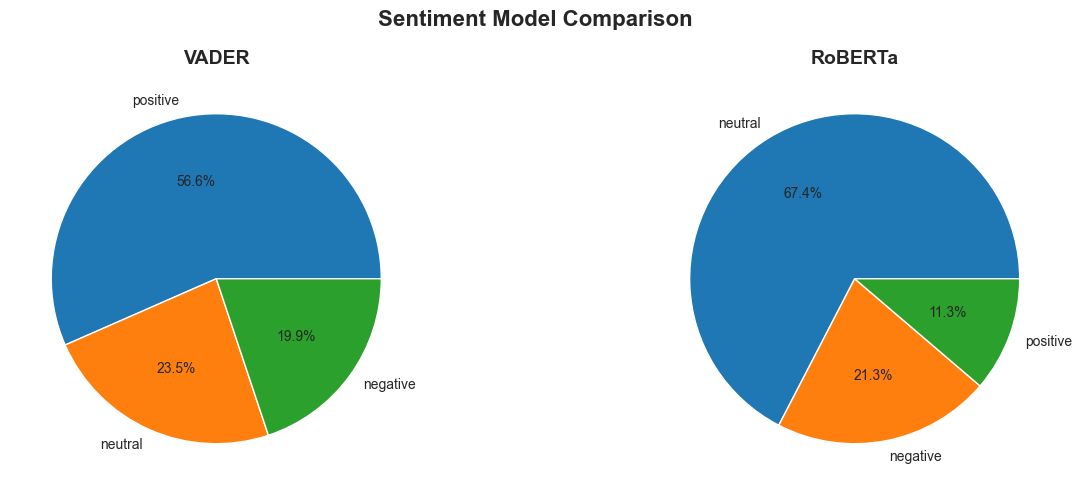

In [7]:
# compare vader vs roberta
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# vader pie
vader_counts = reddit["vader_label"].value_counts()
axes[0].pie(vader_counts, labels=vader_counts.index, autopct="%1.1f%%")
axes[0].set_title("VADER", fontsize=14, fontweight="bold")

# roberta pie
roberta_counts = reddit["roberta_label"].value_counts()
axes[1].pie(roberta_counts, labels=roberta_counts.index, autopct="%1.1f%%")
axes[1].set_title("RoBERTa", fontsize=14, fontweight="bold")

plt.suptitle("Sentiment Model Comparison", fontsize=16, fontweight="bold")
plt.tight_layout()
plt.savefig("../../reports/reddit_reports/sentiment_comparison.png", dpi=150, bbox_inches="tight")
plt.show()

## 3. Sentiment Trends Over Time
the key visualization — how did sentiment shift after chatgpt?

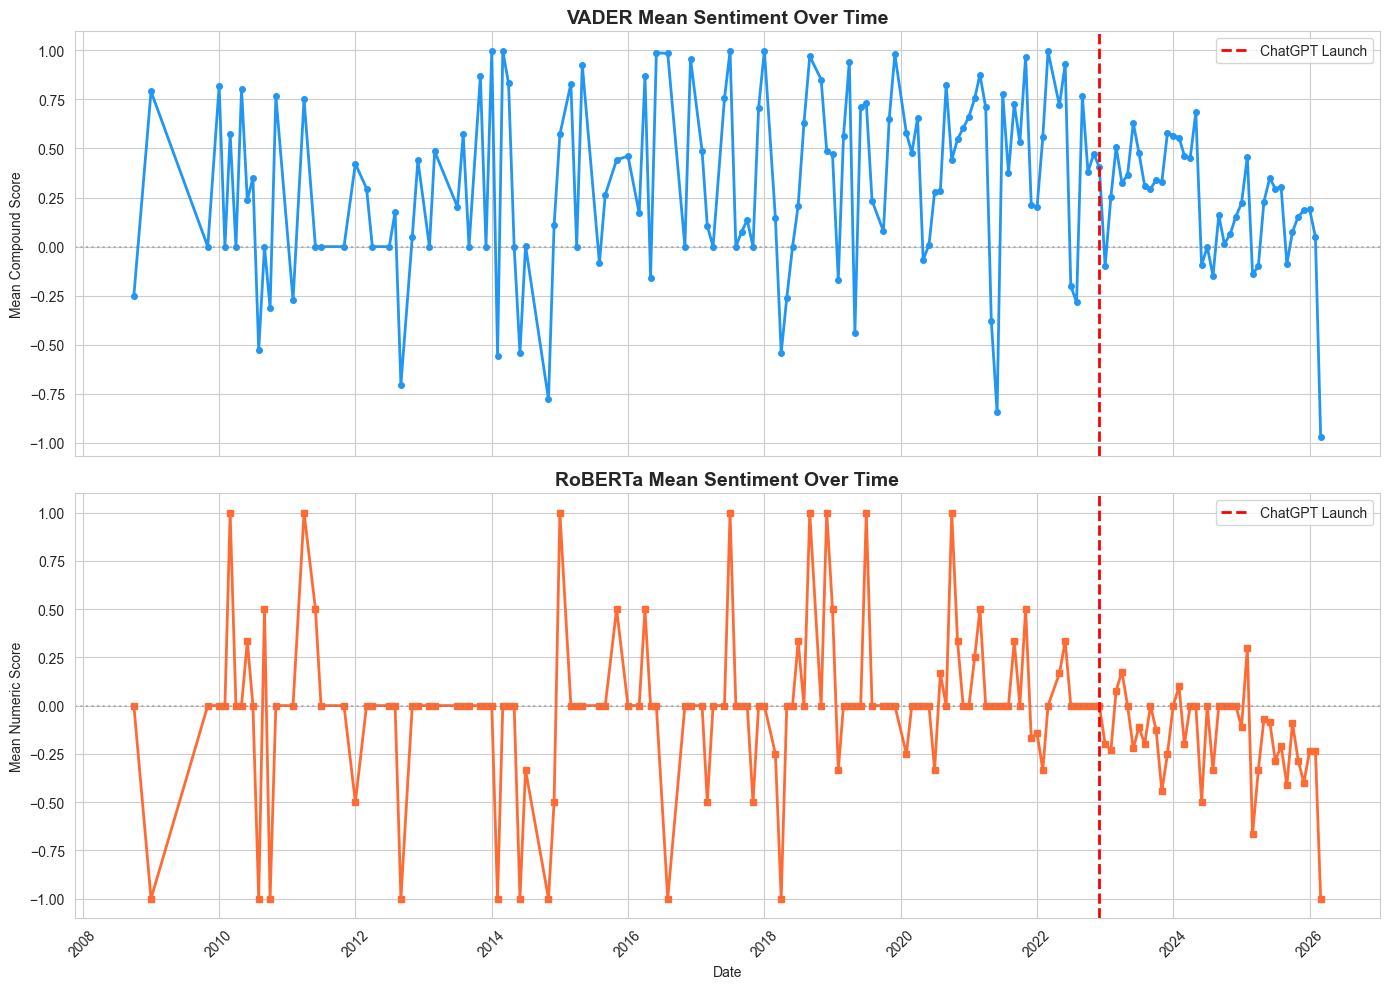

In [8]:
# aggregate by month
monthly_sent = aggregate_sentiment_by_month(reddit, date_col="date")

fig, axes = plt.subplots(2, 1, figsize=(14, 10), sharex=True)

# vader trend
axes[0].plot(monthly_sent["month"], monthly_sent["vader_mean"], color="#2196F3", linewidth=2, marker="o", markersize=4)
axes[0].axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2, label="ChatGPT Launch")
axes[0].axhline(y=0, color="gray", linestyle=":", alpha=0.5)
axes[0].set_title("VADER Mean Sentiment Over Time", fontsize=14, fontweight="bold")
axes[0].set_ylabel("Mean Compound Score")
axes[0].legend()

# roberta trend
if "roberta_mean" in monthly_sent.columns:
    axes[1].plot(monthly_sent["month"], monthly_sent["roberta_mean"], color="#FF6B35", linewidth=2, marker="s", markersize=4)
    axes[1].axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2, label="ChatGPT Launch")
    axes[1].axhline(y=0, color="gray", linestyle=":", alpha=0.5)
    axes[1].set_title("RoBERTa Mean Sentiment Over Time", fontsize=14, fontweight="bold")
    axes[1].set_ylabel("Mean Numeric Score")
    axes[1].legend()

plt.xlabel("Date")
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../reports/reddit_reports/sentiment_over_time.png", dpi=150, bbox_inches="tight")
plt.show()

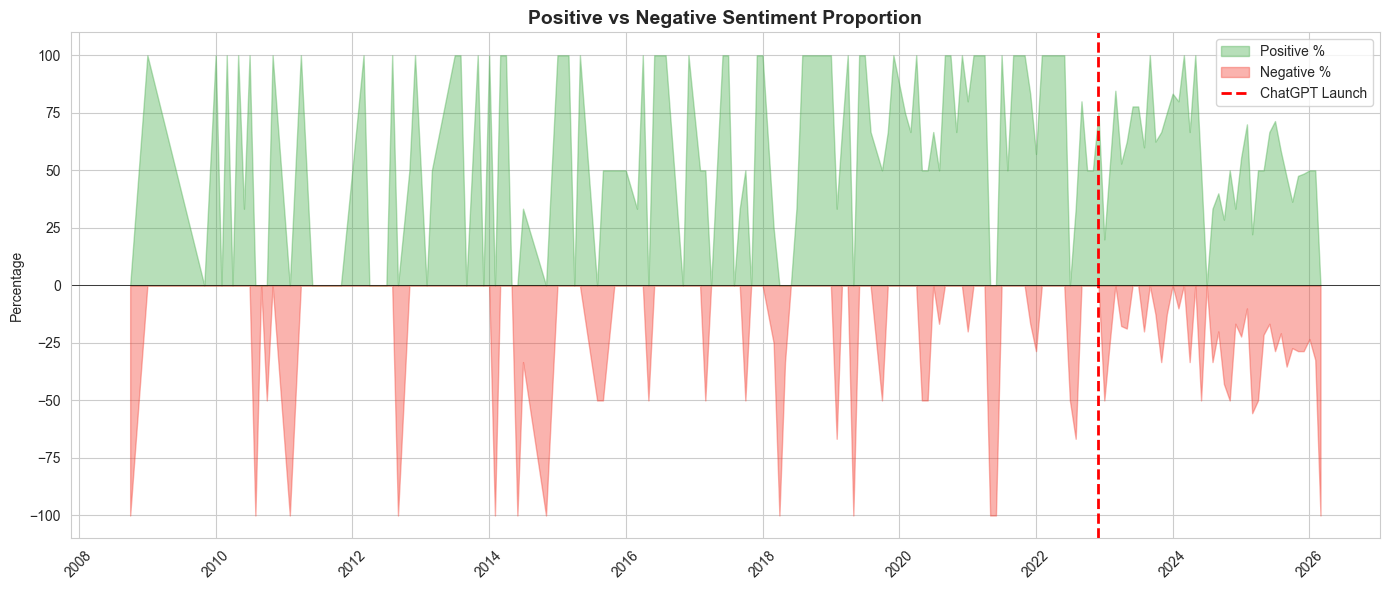

In [9]:
# stacked area — positive vs negative percentage over time
fig, ax = plt.subplots(figsize=(14, 6))

ax.fill_between(monthly_sent["month"], monthly_sent["positive_pct"], alpha=0.4, color="#4CAF50", label="Positive %")
ax.fill_between(monthly_sent["month"], -monthly_sent["negative_pct"], alpha=0.4, color="#F44336", label="Negative %")
ax.axvline(x=CHATGPT_LAUNCH, color="red", linestyle="--", linewidth=2, label="ChatGPT Launch")
ax.axhline(y=0, color="black", linewidth=0.5)

ax.set_title("Positive vs Negative Sentiment Proportion", fontsize=14, fontweight="bold")
ax.set_ylabel("Percentage")
ax.legend()
plt.xticks(rotation=45)
plt.tight_layout()
plt.savefig("../../reports/reddit_reports/sentiment_pct.png", dpi=150, bbox_inches="tight")
plt.show()

## 4. Before vs After ChatGPT — Statistical Comparison

C:\Users\Sumithra\AppData\Local\Temp\ipykernel_35556\486754000.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reddit_tagged, x="period", y="vader_compound", ax=axes[0], palette=["#64B5F6", "#EF5350"])
C:\Users\Sumithra\AppData\Local\Temp\ipykernel_35556\486754000.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=reddit_tagged, x="period", y="roberta_numeric", ax=axes[1], palette=["#64B5F6", "#EF5350"])


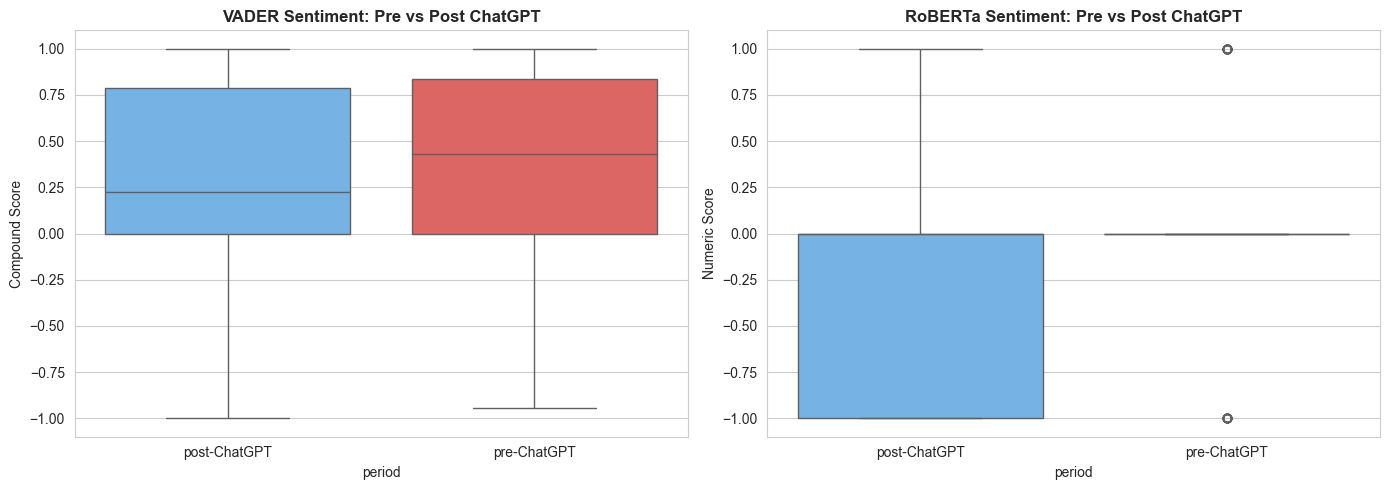


sentiment summary by period:
              count  vader_mean  vader_median
period                                       
post-ChatGPT    434       0.228         0.226
pre-ChatGPT     250       0.358         0.433


In [10]:
reddit_tagged = add_pre_post_chatgpt(reddit, date_col="date")

# box plot comparison
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sns.boxplot(data=reddit_tagged, x="period", y="vader_compound", ax=axes[0], palette=["#64B5F6", "#EF5350"])
axes[0].set_title("VADER Sentiment: Pre vs Post ChatGPT", fontweight="bold")
axes[0].set_ylabel("Compound Score")

if "roberta_numeric" in reddit_tagged.columns:
    sns.boxplot(data=reddit_tagged, x="period", y="roberta_numeric", ax=axes[1], palette=["#64B5F6", "#EF5350"])
    axes[1].set_title("RoBERTa Sentiment: Pre vs Post ChatGPT", fontweight="bold")
    axes[1].set_ylabel("Numeric Score")

plt.tight_layout()
plt.savefig("../../reports/reddit_reports/sentiment_before_after.png", dpi=150, bbox_inches="tight")
plt.show()

# numerical summary
print("\nsentiment summary by period:")
summary = reddit_tagged.groupby("period").agg(
    count=("vader_compound", "count"),
    vader_mean=("vader_compound", "mean"),
    vader_median=("vader_compound", "median")
).round(3)
print(summary)

In [11]:
# save the sentiment-enriched data for later notebooks
reddit.to_csv("../../data/processed/reddit_processed/reddit_with_sentiment.csv", index=False)
monthly_sent.to_csv("../../data/processed/reddit_processed/monthly_sentiment.csv", index=False)
print("saved processed sentiment data")

saved processed sentiment data
